# Darts.models.Output() for saving data, property evaluation and well time series
- The new output class moves the property evaluation and save functions of DARTS from the dartsmodel to the output class
- The general idea is to allow the use to decide where, when and how to save data during simulation and evaluate properties. This is necessary for very large models, or when employing DARTS with ensembles. 
- New features include: saving with single-precision, restart functionality, evaluating properties from *.h5 or engine.X, quick plots with xarray, timers, well time series/plots from *.h5, and an "all_phase_props" option
- the "all_phase_props" functionality creates property_itors based on a predefined list of phase_props in the property_containers 

In [2]:
import numpy as np
import pandas as pd
import sys
import xarray as xr
import h5py
import matplotlib.pyplot as plt
import time

from darts.tools.hdf5_tools import *
from model import Model
from darts.engines import value_vector, redirect_darts_output
from darts.physics.base.operators_base import PropertyOperators as props
from darts.print_build_info import *

In [3]:
def prop_plot(path, property_array):
    for i, name in enumerate(property_array.keys()):
        plt.figure()
        plt.title(name)
        plt.plot(property_array[name][:, :1000].T)
        #plt.savefig(os.path.join(path, name + '.png'))
        plt.show()

def read_data(sol_filepath, well_filepath, timestep = None):
    # read reservoir data
    time, cell_id, X, var_names = n.output.read_specific_data(sol_filepath, timestep = timestep)
    print('time', time)
    print('cell id:', cell_id)
    print('vars:', var_names)
    print('X[time, cell_id, variable], shape:', X.shape)

    # read well data
    time, cell_id, X, var_names = n.output.read_specific_data(well_filepath, timestep = timestep)
    print('time', time)
    print('cell id:', cell_id)
    print('vars:', var_names)
    print('X[time, cell_id, variable], shape:', X.shape)

    print('--------------------------------------------------------------------------------------------------------------')

## Run the model
By default, the initial state of the reservoir is saved. If you do not want to save any data set 'save_initial', 'save_well_data' and 'save_reservoir_data' to **False**. 

In [4]:
from model import Model
n = Model()
n.init()
# the output class requires the reservoir and physics class. 
n.set_output(output_folder = 'data/case_0', sol_filename = 'reservoir_solution.h5', well_filename = 'well_data.h5', save_initial = True,
             all_phase_props = False, precision = 'd', verbose = True) 
redirect_darts_output(n.output_folder + '/run_n.log')
Nt = 4
for i in range(Nt):
    n.run(5, verbose = False, save_well_data = True, save_reservoir_data = True) 
n.print_timers()
read_data(n.sol_filepath, n.well_filepath)

darts-package built on 20/01/2025 11:16:45 by georgehadjisot@TUD262889 from v1.1.3-180-gb9027092
Building connection list...
Saving data to data/case_0\reservoir_solution.h5 at 0.0
Saving data to data/case_0\well_data.h5 at 0.001
Saving data to data/case_0\well_data.h5 at 0.003
Saving data to data/case_0\well_data.h5 at 0.007
Saving data to data/case_0\well_data.h5 at 0.015
Saving data to data/case_0\well_data.h5 at 0.031
Saving data to data/case_0\well_data.h5 at 0.063
Saving data to data/case_0\well_data.h5 at 0.127
Saving data to data/case_0\well_data.h5 at 0.255
Saving data to data/case_0\well_data.h5 at 0.511
Saving data to data/case_0\well_data.h5 at 1.0230000000000001
Saving data to data/case_0\well_data.h5 at 1.5230000000000001
Saving data to data/case_0\well_data.h5 at 2.523
Saving data to data/case_0\well_data.h5 at 3.023
Saving data to data/case_0\well_data.h5 at 4.023
Saving data to data/case_0\well_data.h5 at 5.0
Saving data to data/case_0\reservoir_solution.h5 at 5.0
Savi

## Evaluate properties
Properties can be evaluated from the engine or from the *.h5 file. The property_array is a dictionary that contains the state variables and the properties. By default, all available properties are evaluated. 

In [5]:
# evaluate all available properties and timesteps from *.h5
time, property_array1 = n.output.output_properties(filepath = None, output_properties = None, timestep = None, engine = False)
#prop_plot(n.output_folder, property_array1) 

# evaluate all available properties from last saved timestep
time, property_array2 = n.output.output_properties(filepath = None, output_properties = None, timestep = -1, engine = False)

# evaluate specific properties from last saved timestep
time, property_array3 = n.output.output_properties(filepath = None, output_properties = ['dens0'], timestep = -1, engine = False)

# evaluate all available properties and timesteps from engine
time, property_array4 = n.output.output_properties(filepath = None, output_properties = None, engine = True)

## Output to .vtk 

In [6]:
# Quick plots with xarray
xarray_data = n.output.output_to_xarray() # evaluate properties from *.h5 and save as *.nc file, input is identical to output_properties()
for i in range(Nt + 1):
    n.output.plot_xarray(xarray_data, timestep=i) # these are saved to n.output_folder/figures/

# Or, output to .vtk
# by default, all properties at every time step are exported to .vtk,
n.output.output_to_vtk(filepath = None, ith_step = None, output_directory = None, output_properties = None, engine = False)

# evaluate density at the last time step from *.h5 file
n.output.output_to_vtk(ith_step = Nt, output_directory = n.output_folder + '/vtk_files1', output_properties = ['dens0'], engine = False)

# evaluate density at the last time step from engine
n.output.output_to_vtk(ith_step = Nt, output_directory = n.output_folder + '/vtk_files2', output_properties = ['dens0'], engine = True)

Interpolating missing data in DX...
Interpolating missing data in DY...
Interpolating missing data in DEPTH...


## Wells 
Courtesy of Sajjad and Aleks. 

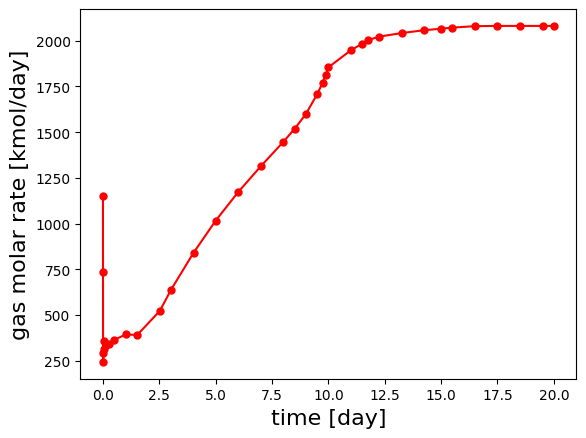

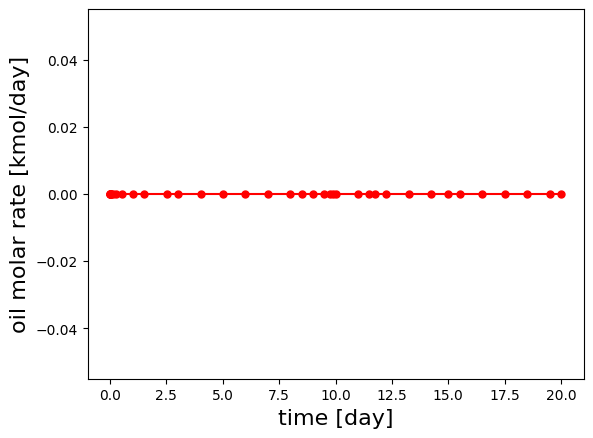

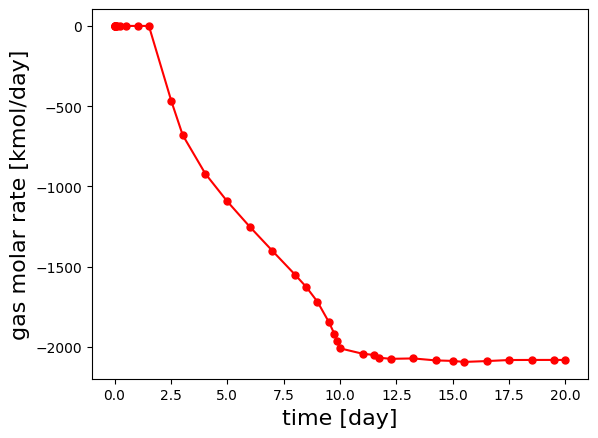

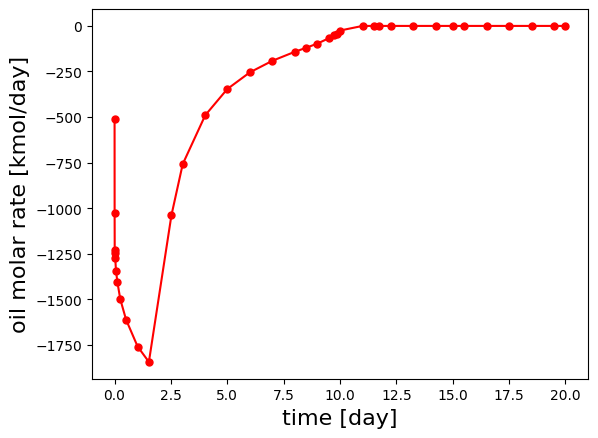

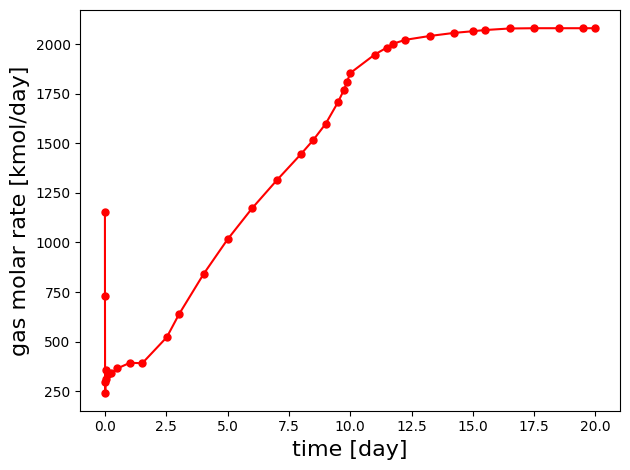

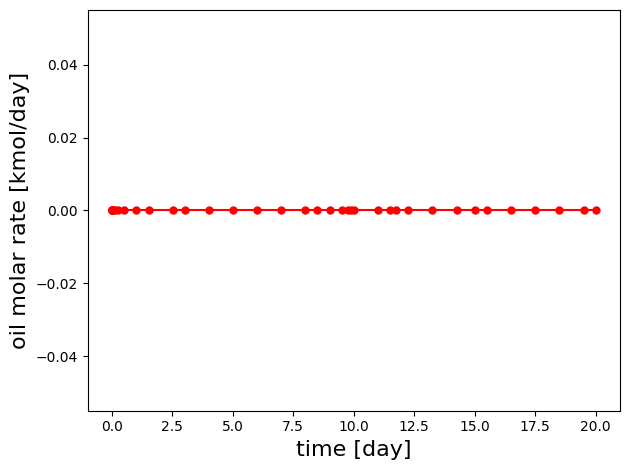

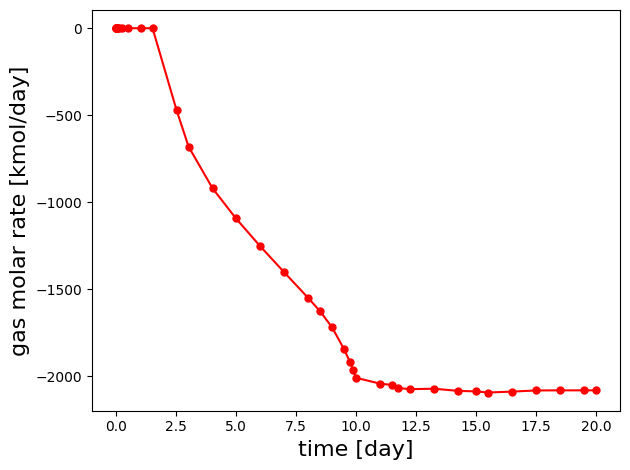

In [7]:
types_of_well_rates = [
    'phases_molar_rates',
    # 'phases_mass_rates',
    # 'phases_volumetric_rates',
    # 'components_molar_rates',
    # 'components_mass_rates'
    # 'heat_rate'
    ]

well_rates_dict = n.output.plot_well_rates(types_of_well_rates)
td = pd.DataFrame.from_dict(well_rates_dict)
td.to_pickle(os.path.join(n.output_folder, "darts_time_data.pkl"))
writer = pd.ExcelWriter(os.path.join(n.output_folder, 'time_data.xlsx'))
td.to_excel(writer, sheet_name='Sheet1')
writer.close()

# plt.figure()
# plt.plot(well_rates_dict['time'], well_rates_dict['well_P1_molar_rate_gas'])
# plt.show()

## Restart with saved *.h5 data
- When restarting, make sure 'save_initial' is set to **False**. 
- If all_phase_props is set to True, a predefined set of phase properties will be defined in 'self.physics.property_containers[region].output_props'.
- Thereafter, users can use the 'self.output.filter_phase_props()' function to only evaluate properties they want. 

In [8]:
from model import Model
m = Model()
m.init()
m.set_output(output_folder = 'data/restarted_from_case0', sol_filename = 'reservoir_solution.h5', save_initial = False,
             all_phase_props = True, precision = 'd', verbose = False)
redirect_darts_output(m.output_folder + '/run_restarted_model.log')

# load point from which to restart
m.output.load_restart_data(reservoir_filename = os.path.join(n.output_folder, 'reservoir_solution.h5'),
                           well_filename = os.path.join(n.output_folder, 'well_data.h5'),
                           timestep = -1)
m.params.first_ts = 1e-9
m.params.max_ts = 1.0
Nt = 3

for i in range(Nt):
    m.run(1, verbose = True, save_well_data = True, save_reservoir_data = True)
m.print_timers()
read_data(m.sol_filepath, m.well_filepath)

# evaluate properties
for i in range(Nt):
    time, property_array = m.output.output_properties(timestep = i)

xarray_data = m.output.output_to_xarray() # evaluate properties from *.h5 and save as *.nc file
m.output.plot_xarray(xarray_data, timestep=Nt)
m.output.output_to_vtk()

# filter properties to only evaluate the properties of interest
m.output.filter_phase_props(['dens_gas', 'dens_oil', 'sat_gas', 'sat_oil', 'nu_gas'])
m.output.output_to_vtk(output_directory = m.output_folder + '/vtk_files1')

darts-package built on 20/01/2025 11:16:45 by georgehadjisot@TUD262889 from v1.1.3-180-gb9027092
Building connection list...
Restarting from ('data/case_0\\reservoir_solution.h5', 'data/case_0\\well_data.h5') at time = 20.000000 days
# 1 	T =  20	DT = 1e-09	NI = 9	LI=9
# 2 	T =  20	DT = 2e-09	NI = 1	LI=1
# 3 	T =  20	DT = 4e-09	NI = 1	LI=1
# 4 	T =  20	DT = 8e-09	NI = 1	LI=1
# 5 	T =  20	DT = 1.6e-08	NI = 1	LI=1
# 6 	T =  20	DT = 3.2e-08	NI = 1	LI=1
# 7 	T =  20	DT = 6.4e-08	NI = 1	LI=1
# 8 	T =  20	DT = 1.28e-07	NI = 1	LI=1
# 9 	T =  20	DT = 2.56e-07	NI = 1	LI=1
# 10 	T =  20	DT = 5.12e-07	NI = 1	LI=1
# 11 	T =  20	DT = 1.024e-06	NI = 1	LI=1
# 12 	T =  20	DT = 2.048e-06	NI = 1	LI=1
# 13 	T =  20	DT = 4.096e-06	NI = 1	LI=1
# 14 	T =  20	DT = 8.192e-06	NI = 1	LI=1
# 15 	T =  20	DT = 1.6384e-05	NI = 1	LI=1
# 16 	T = 20.0001	DT = 3.2768e-05	NI = 1	LI=1
# 17 	T = 20.0001	DT = 6.5536e-05	NI = 1	LI=1
# 18 	T = 20.0003	DT = 0.000131072	NI = 1	LI=1
# 19 	T = 20.0005	DT = 0.000262144	NI = 1	LI=

## Feedback
- Are there any other features that you think would be useful in this class? For example, exporting figures as .gifs, quick plots for unstructured grids, etc. 
- Do you like the default settings?
- ...  